In [76]:
import pandas as pd
import numpy as np
import skfuzzy as fuzz
from collections import defaultdict
import matplotlib.pyplot as plt

In [77]:
df = pd.read_csv("./datasets/mackey_glass.csv")
print(f"Data loaded. Total length: {len(df)}")

split_ratio = 0.8
split_idx = int(split_ratio * len(df))

train_df = df.iloc[:split_idx].copy()
test_df  = df.iloc[split_idx:].copy()

train_values = train_df["value"].values          # آرایه numpy با ۸۰۰ مقدار
test_values  = test_df['value'].values

print(f"Train: {len(train_df)} samples  ({split_ratio*100:.0f}%)")
print(f"Test: {len(test_df)} samples   ({(1-split_ratio)*100:.0f}%)")

Data loaded. Total length: 1000
Train: 800 samples  (80%)
Test: 200 samples   (20%)


In [78]:
y_min = train_df["value"].min()
y_max = train_df["value"].max()
D = 0.2 * (y_max - y_min)
U_min = y_min - D
U_max = y_max + D

print(f"U_min: {U_min:.4f}    U_max: {U_max:.4f}")

U_min: -0.2609    U_max: 1.8168


In [79]:
series_train = train_df["value"].values
n = len(series_train)
tau = 17
m = 3

N = n - (m - 1) * tau
X = np.zeros((N, m))
for i in range(m):
    X[:, i] = series_train[i*tau : i*tau + N]

print(f"Phase space shape (train): {X.shape}")

Phase space shape (train): (766, 3)


c= 2 → PC = 0.3351
c= 3 → PC = 0.1994
c= 4 → PC = 0.1395
c= 5 → PC = 0.1031
c= 6 → PC = 0.0821
c= 7 → PC = 0.0691
c= 8 → PC = 0.0601
c= 9 → PC = 0.0511
c=10 → PC = 0.0442
c=11 → PC = 0.0394


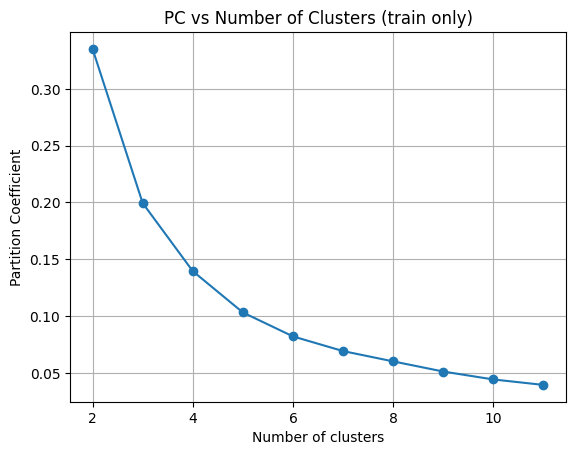

In [80]:
pcs = []
for c in range(2, 12):
    cntr, u, _, _, _, _, _ = fuzz.cluster.cmeans(
        X.T, c=c, m=2.0, error=0.005, maxiter=1000
    )
    pc = np.mean(u**2)
    pcs.append(pc)
    print(f"c={c:2d} → PC = {pc:.4f}")

plt.plot(range(2, 12), pcs, 'o-')
plt.xlabel("Number of clusters")
plt.ylabel("Partition Coefficient")
plt.title("PC vs Number of Clusters (train only)")
plt.grid(True)
plt.show()

In [81]:
c_selected = 5        # ← اینجا بر اساس پلات PC انتخاب کن (مثلاً 5 یا 6 یا 7)
print(f"\nSelected number of clusters: {c_selected}")

cntr, u, _, _, _, _, _ = fuzz.cluster.cmeans(
    X.T, c=c_selected, m=2.0, error=0.005, maxiter=1000
)

# مرتب‌سازی مراکز بر اساس بعد اول (معمولاً کافی است)
centers = np.sort(cntr[:, 0])
print("Sorted centers:", centers)


Selected number of clusters: 5
Sorted centers: [0.25784711 0.66006739 0.67263341 1.1820965  1.19986875]


In [82]:
boundaries = [(centers[i] + centers[i+1])/2 for i in range(len(centers)-1)]

intervals = [(U_min, boundaries[0])]
for i in range(len(boundaries)-1):
    intervals.append((boundaries[i], boundaries[i+1]))
intervals.append((boundaries[-1], U_max))

fuzzy_sets = []
for i in range(len(centers)):
    if i == 0:
        a, b, c = intervals[0][0], centers[0], centers[1]
    elif i == len(centers)-1:
        a, b, c = centers[-2], centers[-1], intervals[-1][1]
    else:
        a, b, c = centers[i-1], centers[i], centers[i+1]
    fuzzy_sets.append((a, b, c))

print("\nFuzzy sets (triangular):")
for i, (a,b,c) in enumerate(fuzzy_sets, 1):
    print(f"A{i}:  {a:>8.4f} → {b:>8.4f} → {c:>8.4f}")


Fuzzy sets (triangular):
A1:   -0.2609 →   0.2578 →   0.6601
A2:    0.2578 →   0.6601 →   0.6726
A3:    0.6601 →   0.6726 →   1.1821
A4:    0.6726 →   1.1821 →   1.1999
A5:    1.1821 →   1.1999 →   1.8168


In [83]:
def triangular_mf(x, a, b, c):
    if x <= a or x >= c:
        return 0.0
    if x <= b:
        return (x - a) / (b - a) if b != a else 0.0
    return (c - x) / (c - b) if c != b else 0.0

def fuzzify(value, fuzzy_sets):
    mfs = [triangular_mf(value, *fs) for fs in fuzzy_sets]
    return np.argmax(mfs)

In [84]:
all_values = df["value"].values
labels = np.array([fuzzify(v, fuzzy_sets) for v in all_values])

print("\nUnique labels:", np.unique(labels))
print("First 15 labels:", labels[:15])


Unique labels: [0 1 2 3 4]
First 15 labels: [1 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [85]:
def which_partition(value, fuzzy_sets):
    """
    ورودی: یک مقدار واقعی (float)
    خروجی: شماره پارتیشن (0-based) که بیشترین درجه عضویت را دارد
    """
    memberships = []
    
    for a, b, c in fuzzy_sets:
        if value <= a or value >= c:
            mu = 0.0
        elif value <= b:
            mu = (value - a) / (b - a) if b != a else 0.0
        else:
            mu = (c - value) / (c - b) if c != b else 0.0
        memberships.append(mu)
    
    if max(memberships) == 0:
        # fallback: نزدیک‌ترین مرکز
        # اگر centers رو پاس ندادی، می‌تونی این قسمت رو حذف کنی یا مقدار None برگردونی
        return None   # یا len(fuzzy_sets)-1 یا هر منطق دیگری
    
    return np.argmax(memberships)



In [86]:

# فقط train

# محاسبه پارتیشن برای همه نقاط train
train_partitions = []
for val in train_values:
    idx = which_partition(val, fuzzy_sets)
    if idx is None:
        # اگر خارج از همه بازه‌ها بود (نادر است)
        train_partitions.append(-1)   # یا می‌توانی نزدیک‌ترین را پیدا کنی
    else:
        train_partitions.append(idx)

# تبدیل به آرایه numpy (اختیاری اما سریع‌تر)
train_partitions = np.array(train_partitions)

# نمایش چند نمونه
print("چند نمونه از پارتیشن‌های train:")
for i in range(min(10, len(train_partitions))):
    print(f"  t={i:3d} | value={train_values[i]:.4f} → A{train_partitions[i]+1}")

# چک کلی
unique_parts, counts = np.unique(train_partitions, return_counts=True)
print("\nتوزیع پارتیشن‌ها در train:")
for p, cnt in zip(unique_parts, counts):
    if p == -1:
        print(f"خارج از بازه‌ها (-1): {cnt} مورد")
    else:
        print(f"A{p+1}: {cnt} مورد")

چند نمونه از پارتیشن‌های train:
  t=  0 | value=0.5000 → A2
  t=  1 | value=0.4500 → A1
  t=  2 | value=0.4050 → A1
  t=  3 | value=0.3645 → A1
  t=  4 | value=0.3281 → A1
  t=  5 | value=0.2952 → A1
  t=  6 | value=0.2657 → A1
  t=  7 | value=0.2391 → A1
  t=  8 | value=0.2152 → A1
  t=  9 | value=0.1937 → A1

توزیع پارتیشن‌ها در train:
A1: 215 مورد
A2: 142 مورد
A3: 169 مورد
A4: 148 مورد
A5: 126 مورد


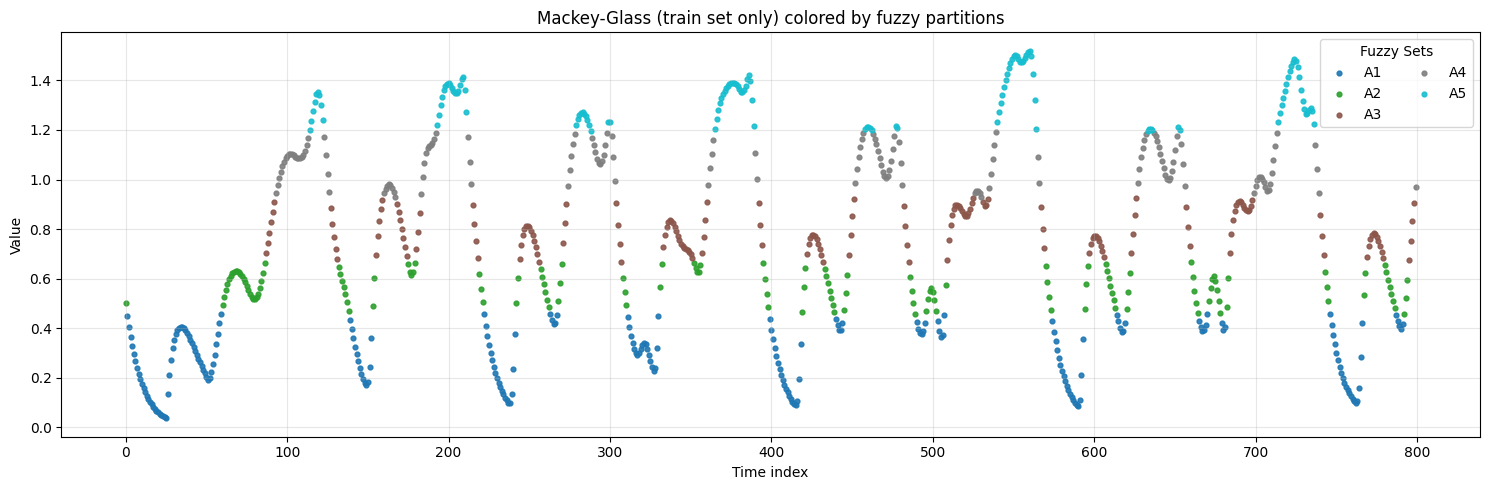

In [87]:
n_clusters = len(fuzzy_sets)
colors = plt.cm.tab10(np.linspace(0, 1, n_clusters))

# فقط train
train_values = train_df["value"].values               # یا all_values[:800]
train_labels = labels[:len(train_df)]                 # یا labels[:800]
train_indices = np.arange(len(train_df))              # یا df.index[:len(train_df)]

plt.figure(figsize=(15, 5))

for lbl in range(n_clusters):
    mask = (train_labels == lbl)
    plt.scatter(
        train_indices[mask],
        train_values[mask],
        color=colors[lbl],
        s=12,
        label=f"A{lbl+1}",
        alpha=0.9
    )

plt.title("Mackey-Glass (train set only) colored by fuzzy partitions")
plt.xlabel("Time index")
plt.ylabel("Value")
plt.legend(title="Fuzzy Sets", loc='upper right', ncol=2)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [88]:
# فرض می‌کنیم labels آرایه numpy یا لیست است (ایندکس از 0)
# centers آرایه مرتب‌شده مراکز خوشه‌هاست (طول = n_clusters)

n_clusters = len(centers)
labels_train = labels[:len(train_df)]   # فقط train

# ────────────────────────────────────────────────
# ساخت FLRG به صورت دیکشنری
# کلید: ایندکس مجموعه فازی فعلی (0-based)
# مقدار: لیست مجموعه‌های فازی بعدی که ظاهر شده‌اند
# ────────────────────────────────────────────────

flrg = defaultdict(lambda: defaultdict(int))

for t in range(len(labels_train) - 1):
    current = labels_train[t]
    next_one = labels_train[t+1]
    flrg[current][next_one] += 1

print("FLRG (First-Order, Weighted):")
for lhs in sorted(flrg.keys()):
    rhs_parts = []
    for rhs, count in flrg[lhs].items():
        rhs_parts.append(f"A{rhs+1}({count})")
    print(f"A{lhs+1} → {', '.join(rhs_parts)}")

FLRG (First-Order, Weighted):
A1 → A1(200), A2(15)
A2 → A1(15), A2(112), A3(15)
A3 → A3(144), A4(11), A2(14)
A4 → A4(126), A5(11), A3(10)
A5 → A5(115), A4(11)


In [101]:
order = 2

# به جای set از شمارنده استفاده می‌کنیم
flrg_ho = defaultdict(lambda: defaultdict(int))

for t in range(order, len(labels_train)):
    lhs = tuple(labels_train[t-order : t])   # مثلاً (3,1)
    rhs = labels_train[t]
    flrg_ho[lhs][rhs] += 1   # افزایش تعداد تکرار

print(f"FLRG (High-Order Weighted, order={order}):")
print("-" * 50)

for lhs_tuple in sorted(flrg_ho.keys()):
    lhs_str = " → ".join(f"A{i+1}" for i in lhs_tuple)
    
    rhs_parts = []
    for rhs, count in flrg_ho[lhs_tuple].items():
        rhs_parts.append(f"A{rhs+1}({count})")
    
    print(f"{lhs_str}  →  {', '.join(rhs_parts)}")

print(f"\nتعداد قوانین منحصربه‌فرد پیدا شده: {len(flrg_ho)}")


FLRG (High-Order Weighted, order=2):
--------------------------------------------------
A1 → A1  →  A1(185), A2(15)
A1 → A2  →  A2(14), A3(1)
A2 → A1  →  A1(15)
A2 → A2  →  A2(84), A3(14), A1(14)
A2 → A3  →  A3(15)
A3 → A2  →  A2(14)
A3 → A3  →  A3(119), A4(11), A2(14)
A3 → A4  →  A4(10)
A4 → A3  →  A3(10)
A4 → A4  →  A4(105), A5(11), A3(10)
A4 → A5  →  A5(11)
A5 → A4  →  A4(11)
A5 → A5  →  A5(104), A4(11)

تعداد قوانین منحصربه‌فرد پیدا شده: 13


In [102]:
def defuzzify_weighted(rhs_dict, centers):
    """
    rhs_dict = {cluster_index: frequency}
    """
    if not rhs_dict:
        return np.nan
    
    num = 0.0
    den = 0.0
    
    for idx, freq in rhs_dict.items():
        num += centers[idx] * freq
        den += freq
    
    return num / den


def predict_fofts(current_idx, flrg, centers):
    if current_idx not in flrg or not flrg[current_idx]:
        return centers[current_idx]
    return defuzzify_weighted(flrg[current_idx], centers)


def predict_hofts(prev_seq, flrg_ho, centers, order):
    key = tuple(prev_seq)
    if key not in flrg_ho or not flrg_ho[key]:
        return centers[prev_seq[-1]]
    return defuzzify_weighted(flrg_ho[key], centers)

In [103]:
def evaluate_model_on_data(
    values,           # np.array مقادیر واقعی
    start_labels,     # لیست یا آرایه پارتیشن‌های اولیه (برای شروع پیش‌بینی)
    flrg, flrg_ho, centers, order=2,
    model_type='both'
):
    if len(values) < 2:
        return None, None, None

    actual = values[1:]           # از گام دوم به بعد
    preds_fofts = []
    preds_hofts = []

    # FOFTS
    if model_type in ['fofts', 'both']:
        current = start_labels[-1]   # آخرین پارتیشن قبل از شروع
        for _ in range(len(values)-1):
            pred = predict_fofts(current, flrg, centers)
            preds_fofts.append(pred)
            current = which_partition(pred, fuzzy_sets)   # closed-loop

    # HOFTS
    if model_type in ['hofts', 'both']:
        current_seq = list(start_labels[-order:])   # آخرین order پارتیشن
        for _ in range(len(values)-1):
            pred = predict_hofts(current_seq, flrg_ho, centers, order)
            preds_hofts.append(pred)
            next_p = which_partition(pred, fuzzy_sets)
            current_seq = current_seq[1:] + [next_p]

    results = {}
    if preds_fofts:
        preds_fofts = np.array(preds_fofts)
        mse  = np.mean((actual - preds_fofts)**2)
        rmse = np.sqrt(mse)
        mae  = np.mean(np.abs(actual - preds_fofts))
        results['fofts'] = (mse, rmse, mae)

    if preds_hofts:
        preds_hofts = np.array(preds_hofts)
        mse  = np.mean((actual - preds_hofts)**2)
        rmse = np.sqrt(mse)
        mae  = np.mean(np.abs(actual - preds_hofts))
        results['hofts'] = (mse, rmse, mae)

    return results

In [104]:
print("ارزیابی closed-loop روی مجموعه تست:")
results_test = evaluate_model_on_data(
    test_values,
    start_labels = train_labels,           # از انتهای train شروع می‌کنیم
    flrg=flrg,
    flrg_ho=flrg_ho,
    centers=centers,
    order=2,
    model_type='both'
)

if 'fofts' in results_test:
    mse_f, rmse_f, mae_f = results_test['fofts']
    print("FOFTS روی تست (closed-loop):")
    print(f" MSE = {mse_f:.6f}")
    print(f" RMSE = {rmse_f:.4f}")
    print(f" MAE = {mae_f:.4f}\n")

if 'hofts' in results_test:
    mse_h, rmse_h, mae_h = results_test['hofts']
    print("HOFTS روی تست (closed-loop):")
    print(f" MSE = {mse_h:.6f}")
    print(f" RMSE = {rmse_h:.4f}")
    print(f" MAE = {mae_h:.4f}\n")

# مقایسه ساده
if 'fofts' in results_test and 'hofts' in results_test:
    print("مقایسه روی تست:")
    print(f"  MSE   →  FOFTS بهتر" if mse_f < mse_h else "  MSE   →  HOFTS بهتر")
    print(f"  RMSE  →  FOFTS بهتر" if rmse_f < rmse_h else "  RMSE  →  HOFTS بهتر")
    print(f"  MAE   →  FOFTS بهتر" if mae_f < mae_h else "  MAE   →  HOFTS بهتر")

ارزیابی closed-loop روی مجموعه تست:
FOFTS روی تست (closed-loop):
 MSE = 0.240315
 RMSE = 0.4902
 MAE = 0.3918

HOFTS روی تست (closed-loop):
 MSE = 0.237022
 RMSE = 0.4868
 MAE = 0.3892

مقایسه روی تست:
  MSE   →  HOFTS بهتر
  RMSE  →  HOFTS بهتر
  MAE   →  HOFTS بهتر
